In [19]:
# Install only wfdb, ignoring systemic dependency conflicts to prevent Colab kernel crashes
!pip install wfdb --no-dependencies

import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

import wfdb
from scipy.signal import butter, filtfilt
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility across runs
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Hardware acceleration config (utilizing T4 GPU if available)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Constants for heartbeat signal segmentation
FS          = 360
HALF_WINDOW = 90
BEAT_LEN    = 2 * HALF_WINDOW

Using device: cuda


In [20]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/ECG_Project'
os.makedirs(DRIVE_PATH, exist_ok=True)
DATA_DIR = os.path.join(DRIVE_PATH, 'mitdb')

if not os.path.exists(DATA_DIR):
    print('Downloading mitdb from PhysioNet...')
    wfdb.dl_database('mitdb', DATA_DIR)
    print('Download completed.')
else:
    print(f'Dataset already present in {DATA_DIR}.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already present in /content/drive/MyDrive/ECG_Project/mitdb.


In [21]:
def get_aami_category(symbol):
    mapping = {
        'N': 'Normal', 'L': 'Normal', 'R': 'Normal', 'e': 'Normal', 'j': 'Normal',
        'A': 'SVEB', 'a': 'SVEB', 'J': 'SVEB', 'S': 'SVEB',
        'V': 'VEB', 'E': 'VEB',
        'F': 'Fusion',
        '/': 'Paced', 'f': 'Paced', 'Q': 'Unknown'
    }
    return mapping.get(symbol, 'Other')

DS1_RECORDS = ['101', '106', '108', '109', '112', '114', '115', '116', '118', '119',
               '122', '124', '201', '203', '205', '207', '208', '209', '215', '220', '223', '230']

DS2_RECORDS = ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202',
               '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']

import random
random.seed(SEED)
shuffled_ds1 = DS1_RECORDS.copy()
random.shuffle(shuffled_ds1)

split_idx = int(0.8 * len(shuffled_ds1))
TRAIN_RECORDS = shuffled_ds1[:split_idx]
VAL_RECORDS   = shuffled_ds1[split_idx:]
TEST_RECORDS  = DS2_RECORDS

print(f'Train records (DS1 sub): {TRAIN_RECORDS}')
print(f'Val records (DS1 sub)  : {VAL_RECORDS}')
print(f'Test records (DS2)      : {TEST_RECORDS}')

Train records (DS1 sub): ['230', '114', '108', '207', '119', '201', '208', '220', '115', '203', '215', '205', '122', '106', '124', '112', '209']
Val records (DS1 sub)  : ['116', '118', '101', '109', '223']
Test records (DS2)      : ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']


In [22]:
def bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=360, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def load_records_hybrid(record_list, dataset_name="Dataset"):
    x_data = []
    intervals_data = []
    y_data = []
    label_map = {'Normal': 0, 'SVEB': 1, 'VEB': 2, 'Fusion': 3}

    for record_id in tqdm(record_list, desc=f"Processing {dataset_name}"):
        path = os.path.join(DATA_DIR, record_id)
        record = wfdb.rdrecord(path)
        signal = bandpass_filter(record.p_signal[:, 0])

        annotation = wfdb.rdann(path, 'atr')
        peaks = annotation.sample
        symbols = annotation.symbol

        for i in range(len(peaks)):
            category = get_aami_category(symbols[i])
            if category in label_map:
                start, end = peaks[i] - HALF_WINDOW, peaks[i] + HALF_WINDOW
                if start > 0 and end < len(signal):
                    segment = signal[start:end]
                    segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)

                    pre_rr = peaks[i] - peaks[i-1] if i > 0 else FS
                    post_rr = peaks[i+1] - peaks[i] if i < len(peaks)-1 else FS

                    intervals = np.array([pre_rr / FS, post_rr / FS], dtype=np.float32)

                    x_data.append(segment)
                    intervals_data.append(intervals)
                    y_data.append(label_map[category])

    return np.array(x_data), np.array(intervals_data), np.array(y_data)

In [23]:
print("Extracting training features (morphology + RR)...")
X_train_raw, Int_train_raw, y_train_raw = load_records_hybrid(TRAIN_RECORDS, "Train Set")

print("Extracting validation features (morphology + RR)...")
X_val, Int_val, y_val = load_records_hybrid(VAL_RECORDS, "Validation Set")

print("Extracting test features (morphology + RR)...")
X_test, Int_test, y_test = load_records_hybrid(TEST_RECORDS, "Test Set (DS2)")

# --- Targeted Oversampling for Minority Classes (SVEB=1, Fusion=3) ---
# We convert rows to lists to perform dynamic iterative duplication
X_train, Int_train, y_train = list(X_train_raw), list(Int_train_raw), list(y_train_raw)

for i in range(len(y_train_raw)):
    # Duplicate SVEB 5 times and Fusion 15 times to forcefully enrich training memory
    if y_train_raw[i] == 1:
        for _ in range(5):
            X_train.append(X_train_raw[i])
            Int_train.append(Int_train_raw[i])
            y_train.append(y_train_raw[i])
    elif y_train_raw[i] == 3:
        for _ in range(15):
            X_train.append(X_train_raw[i])
            Int_train.append(Int_train_raw[i])
            y_train.append(y_train_raw[i])

# Re-convert back to efficient NumPy arrays for downstream processing
X_train, Int_train, y_train = np.array(X_train), np.array(Int_train), np.array(y_train)
# ----------------------------------------------------------------------

inv_label_map = {0: 'Normal (N)', 1: 'SVEB (S)', 2: 'VEB (V)', 3: 'Fusion (F)'}

def print_clean_dist(y, title):
    counts = Counter([int(i) for i in y])
    print(f"\n{title} Distribution:")
    for label, count in sorted(counts.items()):
        print(f" - {inv_label_map[label]}: {count}")

print_clean_dist(y_train, "Augmented Train")
print_clean_dist(y_val, "Validation")
print_clean_dist(y_test, "Test")

Extracting training features (morphology + RR)...


Processing Train Set: 100%|██████████| 17/17 [00:02<00:00,  6.78it/s]


Extracting validation features (morphology + RR)...


Processing Validation Set: 100%|██████████| 5/5 [00:00<00:00,  6.71it/s]


Extracting test features (morphology + RR)...


Processing Test Set (DS2): 100%|██████████| 22/22 [00:03<00:00,  6.12it/s]



Augmented Train Distribution:
 - Normal (N): 34995
 - SVEB (S): 4626
 - VEB (V): 3152
 - Fusion (F): 6368

Validation Distribution:
 - Normal (N): 10861
 - SVEB (S): 173
 - VEB (V): 636
 - Fusion (F): 16

Test Distribution:
 - Normal (N): 44246
 - SVEB (S): 1837
 - VEB (V): 3220
 - Fusion (F): 388


In [24]:
print("Converting NumPy arrays to PyTorch Multi-Input Tensors...")
# Shape alignment: [Batch, Length] -> [Batch, 1, Length]
X_train_t = torch.FloatTensor(X_train).unsqueeze(1)
Int_train_t = torch.FloatTensor(Int_train)
y_train_t = torch.LongTensor(y_train)

X_val_t = torch.FloatTensor(X_val).unsqueeze(1)
Int_val_t = torch.FloatTensor(Int_val)
y_val_t = torch.LongTensor(y_val)

X_test_t = torch.FloatTensor(X_test).unsqueeze(1)
Int_test_t = torch.FloatTensor(Int_test)
y_test_t = torch.LongTensor(y_test)

# Build DataLoaders for iterative network optimization steps
BATCH_SIZE_TRAIN = 128
BATCH_SIZE_EVAL = 256

train_loader = DataLoader(TensorDataset(X_train_t, Int_train_t, y_train_t), batch_size=BATCH_SIZE_TRAIN, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, Int_val_t, y_val_t), batch_size=BATCH_SIZE_EVAL, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, Int_test_t, y_test_t), batch_size=BATCH_SIZE_EVAL, shuffle=False)

Converting NumPy arrays to PyTorch Multi-Input Tensors...


In [25]:
class FocalLoss(nn.Module):
    """Focal Loss function to down-weight easy examples and force gradients onto hard minority classes."""
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        logpt = self.ce(inputs, targets)
        pt = torch.exp(-logpt)
        # Apply scaling factor (1 - pt)^gamma to focus heavily on hard/wrong predictions
        focal_loss = ((1 - pt) ** self.gamma) * logpt
        return focal_loss.mean()

class HybridECGNet(nn.Module):
    def __init__(self, num_classes=4):
        super(HybridECGNet, self).__init__()

        # 1D-CNN pipeline dedicated to morphology pattern learning
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2)
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)

        # Dense Classifier Fusion Subnetwork
        # 128 (CNN Morphology Features) + 2 (Pre/Post RR Timing Features) = 130 inputs
        self.fc1 = nn.Linear(128 + 2, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x, intervals):
        # 1. Morphological extraction path
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.mean(x, dim=2)  # Global Average Pooling layer

        # 2. Context Fusion (Morphology + Rhythm)
        combined = torch.cat((x, intervals), dim=1)

        # 3. Dense classification layers
        combined = F.relu(self.fc1(combined))
        combined = self.dropout(combined)
        return self.fc2(combined)

# Instantiate the network, Focal Loss, and setup the optimizer step size
model = HybridECGNet(num_classes=4).to(DEVICE)
criterion = FocalLoss(gamma=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0002)

print(model)

HybridECGNet(
  (conv1): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=130, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=4, bias=True)
)


In [26]:
EPOCHS = 35  # Increased epochs to let the slower learning rate converge fully
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')

print("Starting training with pure weights and lower learning rate...")
for epoch in range(EPOCHS):
    # Phase A: Training loop
    model.train()
    running_train_loss = 0.0
    for inputs, intervals, labels in train_loader:
        inputs, intervals, labels = inputs.to(DEVICE), intervals.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs, intervals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    # Phase B: Evaluation/Validation loop
    model.eval()
    running_val_loss = 0.0
    correct_predictions = 0
    with torch.no_grad():
        for inputs, intervals, labels in val_loader:
            inputs, intervals, labels = inputs.to(DEVICE), intervals.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs, intervals)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels.data)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_predictions.double() / len(val_loader.dataset)

    # Checkpoint logic to save only if valid loss reaches a new local minimum
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"--> Saved best model checkpoint at epoch {epoch+1}")

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc.item())

    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")

Starting training with pure weights and lower learning rate...
--> Saved best model checkpoint at epoch 1
Epoch 1/35 -> Train Loss: 0.2226 | Val Loss: 0.2697 | Val Acc: 86.58%
Epoch 2/35 -> Train Loss: 0.0754 | Val Loss: 0.5957 | Val Acc: 47.45%
Epoch 3/35 -> Train Loss: 0.0554 | Val Loss: 0.5289 | Val Acc: 53.62%
Epoch 4/35 -> Train Loss: 0.0440 | Val Loss: 0.4698 | Val Acc: 55.37%
Epoch 5/35 -> Train Loss: 0.0375 | Val Loss: 0.3505 | Val Acc: 60.66%
Epoch 6/35 -> Train Loss: 0.0328 | Val Loss: 0.7948 | Val Acc: 38.64%
Epoch 7/35 -> Train Loss: 0.0288 | Val Loss: 0.6007 | Val Acc: 60.51%
Epoch 8/35 -> Train Loss: 0.0265 | Val Loss: 0.5947 | Val Acc: 42.14%
Epoch 9/35 -> Train Loss: 0.0240 | Val Loss: 0.2809 | Val Acc: 77.66%
Epoch 10/35 -> Train Loss: 0.0213 | Val Loss: 0.5556 | Val Acc: 53.33%
Epoch 11/35 -> Train Loss: 0.0205 | Val Loss: 0.9348 | Val Acc: 33.45%
Epoch 12/35 -> Train Loss: 0.0188 | Val Loss: 0.5766 | Val Acc: 37.36%
Epoch 13/35 -> Train Loss: 0.0173 | Val Loss: 0.440


--- CLASSIFICATION REPORT (AAMI/DE CHAZAL HYBRID MODEL) ---
              precision    recall  f1-score   support

  Normal (N)       0.94      0.94      0.94     44246
    SVEB (S)       0.03      0.03      0.03      1837
     VEB (V)       0.94      0.78      0.85      3220
  Fusion (F)       0.00      0.01      0.00       388

    accuracy                           0.89     49691
   macro avg       0.48      0.44      0.46     49691
weighted avg       0.90      0.89      0.89     49691



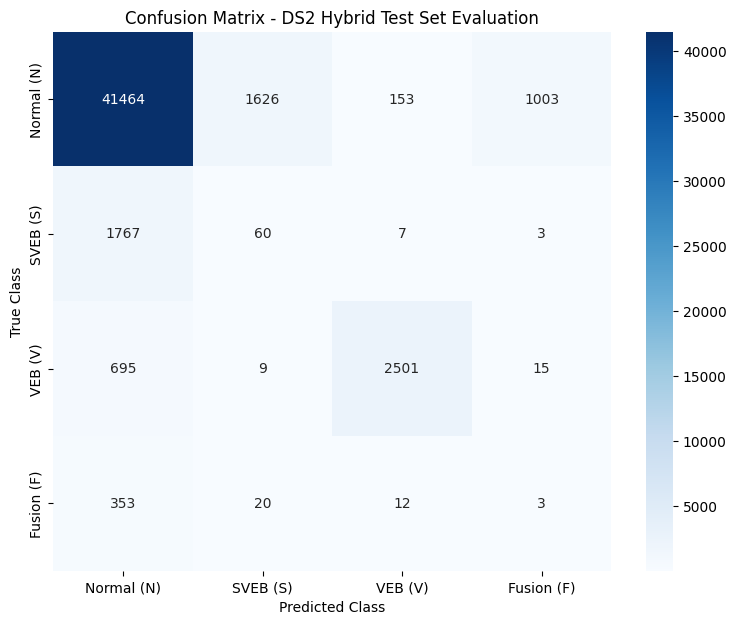

In [27]:
model.eval()
all_preds = []
all_labels = []

model.load_state_dict(torch.load('best_model.pth'))

with torch.no_grad():
    for inputs, intervals, labels in test_loader:
        inputs, intervals = inputs.to(DEVICE), intervals.to(DEVICE)
        outputs = model(inputs, intervals)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

target_names = ['Normal (N)', 'SVEB (S)', 'VEB (V)', 'Fusion (F)']
print("\n--- CLASSIFICATION REPORT (AAMI/DE CHAZAL HYBRID MODEL) ---")
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - DS2 Hybrid Test Set Evaluation')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()